In [6]:
import tensorflow as tf

In [8]:
# Load the Fashion MNIST dataset
fmnist = tf.keras.datasets.fashion_mnist

In [9]:
fmnist

<module 'keras.datasets.fashion_mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/fashion_mnist/__init__.py'>

In [10]:

# Load the training and test split of the Fashion MNIST dataset
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()


IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   1   0   0   0  65  99   0   0   0   0   0   0   0 106  60   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0  17 190 206 202 145 148 146 148 166 165 189 212 210 202   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 160 229 193 189 197 169 182 109 165 156 202 198 196 233  96   0   0   0   0   0   0]
 [  0   0   0   0   0   0   2 199 198 213 193 201 207 196 172 211 206 207 200 202 208 217   0   0   0   0   0   0]
 [  0   0   0   0   0   0 139 205 200 207 190 192 210 210 208 212 208 197 201 210 206 205  83   0   0   0   0   0]
 [  0   0   0   0   0   2 196 220 200 200 190 193 199 222 222 225 199 198 210 212 218 227 189   0   0   0   0   0]
 [  0   0   0   0   0   0   0 162 215 199 192 196 195 204 221 200 195 205 208 218 235 170   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 172 240 192 204 203 206 203 199 206 215 211 232 114   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   2   0   0  32 235 200 206 208 2

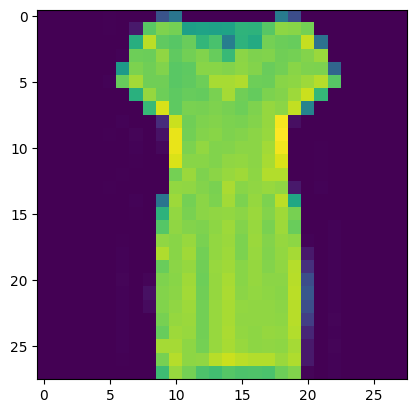

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
# index = 3
index = 20

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
print(f'LABEL: {training_labels[index]}')
plt.imshow(training_images[index])
plt.show()

In [12]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [13]:

# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(), # this is input layer
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu), #this is black box layer
                                     tf.keras.layers.Dense(64, activation=tf.nn.relu), # this is black box layer
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)]) # this is ouput layer

In [14]:
# Declare sample inputs and convert to a tensor
inputs = np.array([[1.0, 3.0, 4.0, 2.0]])
inputs = tf.convert_to_tensor(inputs)
print(f'input to softmax function: {inputs.numpy()}')

# Feed the inputs to a softmax activation function
outputs = tf.keras.activations.softmax(inputs)
print(f'output of softmax function: {outputs.numpy()}')

# Get the sum of all values after the softmax
sum = tf.reduce_sum(outputs)
print(f'sum of outputs: {sum}')

# Get the index with highest value
prediction = np.argmax(outputs)
print(f'class with highest probability: {prediction}')

input to softmax function: [[1. 3. 4. 2.]]
output of softmax function: [[0.0320586  0.23688282 0.64391426 0.08714432]]
sum of outputs: 1.0
class with highest probability: 2


In [15]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8236 - loss: 0.4974
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8659 - loss: 0.3684
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8788 - loss: 0.3316
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8857 - loss: 0.3079
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8908 - loss: 0.2915
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8954 - loss: 0.2785
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9003 - loss: 0.2643
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9040 - loss: 0.2560
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9082 - loss: 0.2446
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9107 - loss: 0.2370
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9154 - loss: 0.2265
Epoch 12/100
1875/1

In [16]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8880 - loss: 0.8687


[0.8686639666557312, 0.8880000114440918]

In [17]:
classifications = model.predict(test_images)
print(classifications[3])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[0.0000000e+00 9.9999994e-01 0.0000000e+00 2.4422433e-31 0.0000000e+00 0.0000000e+00 2.4955724e-34 0.0000000e+00 0.0000000e+00 0.0000000e+00]


In [23]:
print(test_labels[3])

1


Saving shirt.jpeg to shirt.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


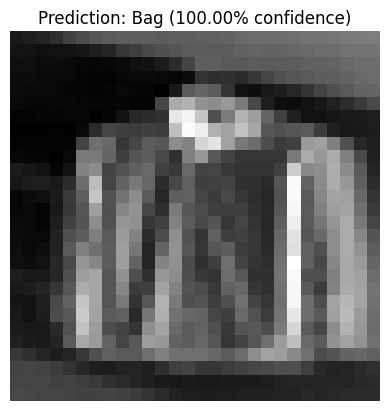

Uploaded file: shirt.jpeg
Predicted class number: 8
Predicted class name: Bag
Confidence: 100.00%
T-shirt/top: 0.00%
Trouser: 0.00%
Pullover: 0.00%
Dress: 0.00%
Coat: 0.00%
Sandal: 0.00%
Shirt: 0.00%
Sneaker: 0.00%
Bag: 100.00%
Ankle boot: 0.00%


In [18]:
# Upload your own image and predict the Fashion MNIST class
# Run this cell AFTER training the model.

from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Upload an image file: png, jpg, jpeg, etc.
uploaded = files.upload()

for file_name in uploaded.keys():
    # 1. Open uploaded image
    img = Image.open(file_name).convert("L")   # convert to grayscale

    # 2. Resize image to 28 x 28 because Fashion MNIST images are 28x28
    img = img.resize((28, 28))
 # 3. Fashion MNIST usually has a dark background and light object.
    # If your uploaded image has a white background, invert it.
    img = ImageOps.invert(img)

    # 4. Convert image into numpy array and normalize values from 0 to 1
    img_array = np.array(img) / 255.0

    # 5. Add batch dimension: model expects shape (1, 28, 28)
    img_input = np.expand_dims(img_array, axis=0)

    # 6. Predict
    prediction = model.predict(img_input)
    predicted_index = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    # 7. Show result
    plt.imshow(img_array, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {class_names[predicted_index]} ({confidence:.2f}% confidence)")
    plt.show()

    print("Uploaded file:", file_name)
    print("Predicted class number:", predicted_index)
    print("Predicted class name:", class_names[predicted_index])
    print(f"Confidence: {confidence:.2f}%")
    for name, prob in zip(class_names, prediction[0]):
        print(f"{name}: {prob*100:.2f}%")

In [19]:
# Install Gradio
!pip install gradio -q

In [2]:
# pip install --upgrade gradio

In [20]:
import gradio as gr
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Fashion MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def predict_fashion_image(uploaded_image):
    """
    This function takes an uploaded image,
    preprocesses it like Fashion MNIST,
    and predicts its class using the trained model.
    """

    # Convert uploaded image to grayscale
    img = uploaded_image.convert("L")

    # Resize image to 28x28 because Fashion MNIST images are 28x28
    img = img.resize((28, 28))

    # Invert image colors to match Fashion MNIST style
    img = ImageOps.invert(img)

    # Convert image to numpy array
    img_array = np.array(img)

    # Normalize pixel values from 0-255 to 0-1
    img_array = img_array / 255.0

    # Add batch dimension: (28, 28) becomes (1, 28, 28)
    img_input = np.expand_dims(img_array, axis=0)

    # Predict using trained model
    prediction = model.predict(img_input)

    # Get predicted class index
    predicted_index = np.argmax(prediction[0])

    # Get confidence percentage
    confidence = np.max(prediction[0]) * 100

    # Create result text
    result = f"Prediction: {class_names[predicted_index]}\nConfidence: {confidence:.2f}%"

    # Return all class probabilities also
    probabilities = {
        class_names[i]: float(prediction[0][i])
        for i in range(len(class_names))
    }

    return result, probabilities


# Create Gradio interface
demo = gr.Interface(
    fn=predict_fashion_image,
    inputs=gr.Image(type="pil", label="Upload Fashion Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Label(num_top_classes=10, label="Class Probabilities")
    ],
    title="Fashion MNIST Image Classifier",
    description="Upload an image of clothing, shoes, or bag. The model will predict the Fashion MNIST class."
)

# Launch app
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7a7b22adebf88e8d0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
